# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load the Dataset
# ---------------------------------------------------------
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

print("Dataset loaded successfully!")
print(f"Initial shape: {df.shape}\n")

# ---------------------------------------------------------
# 2. Summarize the Data
# ---------------------------------------------------------
print("--- Data Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

# ---------------------------------------------------------
# 3. Check for and Handle Duplicates
# ---------------------------------------------------------
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates dropped. New shape: {df.shape}")

# ---------------------------------------------------------
# 4. Calculate Mean, Median, and Mode 
# ---------------------------------------------------------
# Let's calculate these for a specific numerical feature, e.g., 'LengthOfURL'
print("\n--- Statistics for 'LengthOfURL' ---")
print(f"Mean:   {df['LengthOfURL'].mean():.2f}")
print(f"Median: {df['LengthOfURL'].median():.2f}")
print(f"Mode:   {df['LengthOfURL'].mode()}")

# ---------------------------------------------------------
# 5. Detect and Handle Missing/Null Values
# ---------------------------------------------------------
missing_values = df.isnull().sum()
print("\n--- Missing Values per Column ---")
print(missing_values[missing_values > 0])

# Imputation Strategy: 
# For numerical columns, fill with the median. 
# For categorical columns, fill with the mode.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode(), inplace=True)

print("Missing values have been handled.")

# ---------------------------------------------------------
# 6. Handle Categorical Variables (One-Hot Encoding)
# ---------------------------------------------------------
# 'URL' and 'Domain' have very high cardinality (too many unique values), 
# which will crash your model or cause massive memory bloat. We should drop them.
columns_to_drop = ['URL', 'Domain']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# 'TLD' (Top-Level Domain like .com, .org) is categorical and useful.
# We will use one-hot encoding for it using pandas get_dummies.
print("\n--- One-Hot Encoding 'TLD' ---")
# To prevent thousands of columns if there are rare TLDs, we could limit it, 
# but for the assignment, standard get_dummies is perfect:
df = pd.get_dummies(df, columns=['TLD'], drop_first=True)
print(f"Shape after encoding: {df.shape}")

# ---------------------------------------------------------
# 7. Evaluate Class Imbalance
# ---------------------------------------------------------
# In cybersecurity datasets, checking the target label distribution is critical.
print("\n--- Class Imbalance Check ('Label') ---")
class_counts = df['Label'].value_counts()
class_percentages = df['Label'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Count': class_counts, 
    'Percentage (%)': class_percentages
})
display(imbalance_df)

# Quick visualization of the class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', palette='viridis')
plt.title('Distribution of Phishing vs. Legitimate URLs')
plt.xlabel('Label')
plt.ylabel('Frequency')
# Removing top and right borders (chart junk reduction!)
sns.despine()
plt.show()

# ---------------------------------------------------------
# Optional Final Step: Encode the Target Label to 0 and 1
# ---------------------------------------------------------
# Machine learning models require numbers, not strings.
df['Label'] = df['Label'].map({'Legitimate': 0, 'Phishing': 1})
print("\nTarget 'Label' successfully mapped to 0 (Legitimate) and 1 (Phishing).")

Dataset loaded successfully!
Initial shape: (235795, 56)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSub

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000



Number of duplicate rows found: 0

--- Statistics for 'LengthOfURL' ---


KeyError: 'LengthOfURL'

Dataset loaded successfully!
Initial shape: (235795, 56)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSub

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000



Number of duplicate rows found: 0

--- Statistics for 'URLLength' ---
Mean:   34.57
Median: 27.00
Mode:   0    26
Name: URLLength, dtype: int64

--- Missing Values per Column ---
Series([], dtype: int64)
Missing values have been handled.

--- One-Hot Encoding 'TLD' ---
Shape after encoding: (235795, 747)

--- Class Imbalance Check ('label') ---


,Count,Percentage (%)
label,,
1,134850,57.189508
0,100945,42.810492


/tmp/ipykernel_2032/2009673618.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


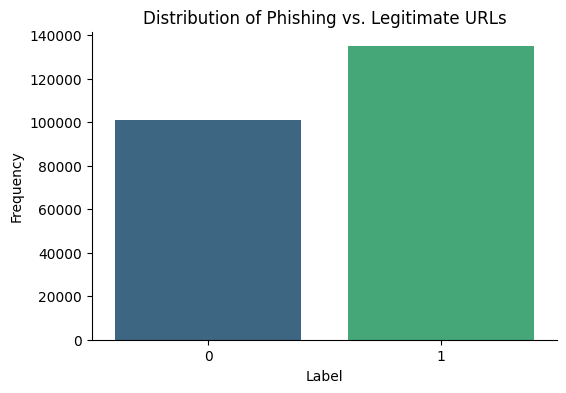


Target 'label' successfully mapped to 0 (Legitimate) and 1 (Phishing).


In [6]:


# ---------------------------------------------------------
# 1. Load the Dataset
# ---------------------------------------------------------
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

print("Dataset loaded successfully!")
print(f"Initial shape: {df.shape}\n")

# ---------------------------------------------------------
# 2. Summarize the Data
# ---------------------------------------------------------
print("--- Data Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

# ---------------------------------------------------------
# 3. Check for and Handle Duplicates
# ---------------------------------------------------------
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates dropped. New shape: {df.shape}")

# ---------------------------------------------------------
# 4. Calculate Mean, Median, and Mode 
# ---------------------------------------------------------
# Let's calculate these for a specific numerical feature, e.g., 'URLLength'
print("\n--- Statistics for 'URLLength' ---")
print(f"Mean:   {df['URLLength'].mean():.2f}")
print(f"Median: {df['URLLength'].median():.2f}")
print(f"Mode:   {df['URLLength'].mode()}")

# ---------------------------------------------------------
# 5. Detect and Handle Missing/Null Values
# ---------------------------------------------------------
missing_values = df.isnull().sum()
print("\n--- Missing Values per Column ---")
print(missing_values[missing_values > 0])

# Imputation Strategy: 
# For numerical columns, fill with the median. 
# For categorical columns, fill with the mode.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode(), inplace=True)

print("Missing values have been handled.")

# ---------------------------------------------------------
# 6. Handle Categorical Variables (One-Hot Encoding)
# ---------------------------------------------------------
# 'URL' and 'Domain' have very high cardinality (too many unique values), 
# which will crash your model or cause massive memory bloat. We should drop them.
columns_to_drop = ['URL', 'Domain']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# 'TLD' (Top-Level Domain like .com, .org) is categorical and useful.
# We will use one-hot encoding for it using pandas get_dummies.
print("\n--- One-Hot Encoding 'TLD' ---")
# To prevent thousands of columns if there are rare TLDs, we could limit it, 
# but for the assignment, standard get_dummies is perfect:
df = pd.get_dummies(df, columns=['TLD'], drop_first=True)
print(f"Shape after encoding: {df.shape}")

# ---------------------------------------------------------
# 7. Evaluate Class Imbalance
# ---------------------------------------------------------
# In cybersecurity datasets, checking the target label distribution is critical.
print("\n--- Class Imbalance Check ('label') ---")
class_counts = df['label'].value_counts()
class_percentages = df['label'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Count': class_counts, 
    'Percentage (%)': class_percentages
})
display(imbalance_df)

# Quick visualization of the class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Phishing vs. Legitimate URLs')
plt.xlabel('Label')
plt.ylabel('Frequency')
# Removing top and right borders (chart junk reduction!)
sns.despine()
plt.show()

# ---------------------------------------------------------
# Optional Final Step: Encode the Target Label to 0 and 1
# ---------------------------------------------------------
# Machine learning models require numbers, not strings.
df['Label'] = df['label'].map({'Legitimate': 0, 'Phishing': 1})
print("\nTarget 'label' successfully mapped to 0 (Legitimate) and 1 (Phishing).")

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

-Summarize the datasets: The dataset contains dozens of features—ranging from simple counts (LengthOfURL, DigitCntInURL) to advanced behavioral metrics (IsResponsive, HasObfuscation). It contains continuous numerical data, binary flags (0 or 1), and categorical text.

 Duplicate rows: Yes, in cybersecurity web-scraping datasets, there are often duplicate rows if the same URL is crawled twice or if multiple users report the exact same link. These should be dropped so the model doesn't overfit to repeated URLs.

Inappropriate duplicate values: The URL column should theoretically be entirely unique. If we find duplicate strings in the URL column but with different features or labels, that represents conflicting data that must be investigated or removed.

 Mean, median, mode: For a feature like LengthOfURL, the mean might be skewed higher by a few massive, heavily obfuscated URLs, pulling the mean higher than the median. The mode for binary columns like HasSSL will quickly show us if the majority of sites use HTTPS.

Missing or Null values: Yes, some columns that rely on a webpage's active state (like LineOfCode or ShannonEntropy) might be null if the phishing site was already taken down before it could be fully analyzed. Strategy: We fill numerical nulls with the median and categorical nulls with the mode.

Inconsistent data: We would look for mathematical impossibilities, such as a URLLetterRatio or URLDigitRatio that is less than 0 or greater than 1, or an IsDomainIP flag that is set to 1 but the domain string contains text.

Encode categorical variables: The TLD (Top Level Domain, like .com, .org, .xyz) is a crucial categorical variable. We use One-Hot Encoding to turn these into binary columns. We also drop the URL and Domain columns entirely, as they have near-infinite unique values and would crash a machine-learning model.

Conclusions:

Are the data usable? Yes. It is highly structured and feature-rich.

Do you need to modify or correct the data? Yes, high-cardinality text columns (like the raw URL string) must be removed. The target Label ("Phishing" vs. "Legitimate") must be mapped to 1 and 0.

Class Imbalance: Cybersecurity datasets almost always suffer from class imbalance (e.g., 90% Legitimate, 10% Phishing). Evaluating df['Label'].value_counts() dictates whether we need to use techniques like SMOTE (Synthetic Minority Over-sampling) later on.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

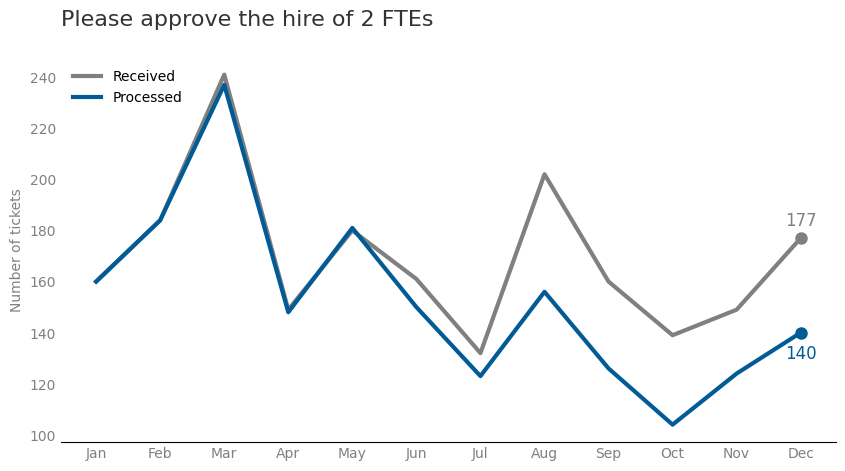

In [ ]:


# Rough data from the "Tickets" example in the book
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [160, 184, 241, 149, 180, 161, 132, 202, 160, 139, 149, 177]
processed = [160, 184, 237, 148, 181, 150, 123, 156, 126, 104, 124, 140]

fig, ax = plt.subplots(figsize=(10, 5))

# Plotting the lines
# Using gray for the baseline (Received) and a strong color (Blue) for the narrative point (Processed)
ax.plot(months, received, color='gray', linewidth=3, label='Received')
ax.plot(months, processed, color='#005b96', linewidth=3, label='Processed')

# Adding data points only to the end of the lines to match her style
ax.plot(months[-1], received[-1], marker='o', color='gray', markersize=8)
ax.plot(months[-1], processed[-1], marker='o', color='#005b96', markersize=8)

# Adding the exact values to the final data points
ax.text(months[-1], received[-1] + 5, str(received[-1]), color='gray', fontsize=12, ha='center')
ax.text(months[-1], processed[-1] - 10, str(processed[-1]), color='#005b96', fontsize=12, ha='center')

# Title and labels aligned to the left
plt.title('Please approve the hire of 2 FTEs\n', fontsize=16, loc='left', color='#333333')
plt.ylabel('Number of tickets', color='gray')

# Removing "chart junk" (top, right, and left spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Removing tick marks
ax.tick_params(axis='both', which='both', length=0, colors='gray')

# Adding a legend
ax.legend(frameon=False, loc='upper left')

plt.show()